# ECON FORECASTING FINAL PROJECT

## Setup


### Library import

In [131]:
import pandas as pd 
import numpy as np 
import os 
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

### Data Loading

In [132]:
indpro = pd.read_csv(os.path.join('data', 'indpro.csv'))
spread = pd.read_csv(os.path.join('data', 'T10Y3M.csv'))

print("===== indrpo data ===== ")
print(indpro.head())
print("===== spread data ===== ")
print(spread.head())

===== indrpo data ===== 
  observation_date  INDPRO
0       1919-01-01  4.8739
1       1919-02-01  4.6585
2       1919-03-01  4.5238
3       1919-04-01  4.6046
4       1919-05-01  4.6315
===== spread data ===== 
  observation_date  T10Y3M
0       2021-04-01    1.61
1       2021-05-01    1.60
2       2021-06-01    1.48
3       2021-07-01    1.27
4       2021-08-01    1.23


## Data Preparation

In [133]:
indpro['observation_date'] = pd.to_datetime(indpro['observation_date'])
spread['observation_date'] = pd.to_datetime(spread['observation_date'])
indpro = indpro.sort_values('observation_date')

# g_t = log(IP_t) - log(IP_{t-12})
indpro["IP_growth"] = np.log(indpro["INDPRO"]) - np.log(indpro["INDPRO"].shift(12))

merged_data = pd.merge(indpro, spread, on='observation_date', how='inner')
print("===== Merged Data ===== ")
print(merged_data.iloc[12:].head())


merged_data['Spread_lag12'] = merged_data['T10Y3M'].shift(12)

print("===== Merged + Spread ===== ")
print(merged_data.iloc[12:].head())


===== Merged Data ===== 
   observation_date    INDPRO  IP_growth  T10Y3M
12       2022-04-01  101.4400   0.028815    1.98
13       2022-05-01  101.3335   0.018930    1.91
14       2022-06-01  101.0180   0.012144    1.60
15       2022-07-01  101.2230   0.009640    0.60
16       2022-08-01  101.0963   0.010466    0.18
===== Merged + Spread ===== 
   observation_date    INDPRO  IP_growth  T10Y3M  Spread_lag12
12       2022-04-01  101.4400   0.028815    1.98          1.61
13       2022-05-01  101.3335   0.018930    1.91          1.60
14       2022-06-01  101.0180   0.012144    1.60          1.48
15       2022-07-01  101.2230   0.009640    0.60          1.27
16       2022-08-01  101.0963   0.010466    0.18          1.23


### Graph

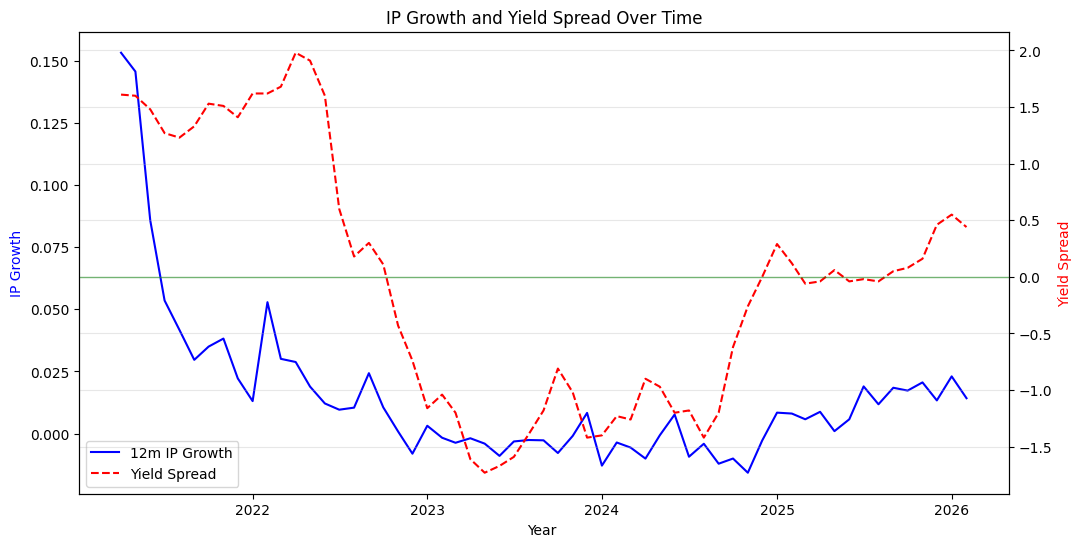

In [134]:
plt.figure(figsize=(12, 6))
ax1 = plt.gca()
ax2 = ax1.twinx()

ip_line = ax1.plot(merged_data['observation_date'], merged_data['IP_growth'], color='blue', label='12m IP Growth')
spread_line = ax2.plot(merged_data['observation_date'], merged_data['T10Y3M'], color='red', linestyle='--', label='Yield Spread')

ax1.set_xlabel('Year ')
ax1.set_ylabel('IP Growth', color='blue')
ax2.set_ylabel('Yield Spread', color='red')

ax2.axhline(0, color='green', linewidth=1, alpha=0.5)

plt.title('IP Growth and Yield Spread Over Time')
plt.grid(True, alpha=0.3)
lines = ip_line + spread_line
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='lower left')

plt.show()

## Lag Selection

In [140]:
lag_table = [] 
for lag in range(1, 13):
    cols = [] 
    temp_df = merged_data.dropna(subset = ['IP_growth']).copy()
    model = ARIMA(temp_df['IP_growth'], order=(lag, 0, 0)).fit()
    lag_table.append({'Lags': lag, 'AIC': model.aic, 'BIC': model.bic})

lag_df = pd.DataFrame(lag_table)
print(lag_df)
best_lag = lag_df.loc[lag_df['AIC'].idxmin(), 'Lags']
print(f"\nBest lag: {best_lag}")

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.wa

    Lags         AIC         BIC
0      1 -332.060256 -325.827644
1      2 -330.523120 -322.212971
2      3 -328.901676 -318.513989
3      4 -327.926418 -315.461193
4      5 -322.150071 -307.607309
5      6 -320.029426 -303.409126
6      7 -321.278547 -302.580710
7      8 -315.716950 -294.941575
8      9 -321.025289 -298.172377
9     10 -315.115323 -290.184874
10    11 -318.893972 -291.885985
11    12 -320.983528 -291.898003

Best lag: 1


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## Train / Test Split

### Train

In [141]:
lag_cols = []
reg_df = merged_data.dropna(subset=['IP_growth', 'Spread_lag12']).copy().reset_index(drop=True)

for i in range(1, best_lag + 1):
    col_name = f'IP_lag{i}'
    reg_df[col_name] = reg_df['IP_growth'].shift(i)
    lag_cols.append(col_name)

final_df = reg_df.dropna().reset_index(drop=True)


split = int(len(final_df) * 0.8)
train = final_df.iloc[:split]
test = final_df.iloc[split:]

ytrain = train['IP_growth']

# ARIMA
model1 = ARIMA(train['IP_growth'], order=(best_lag, 0, 0)).fit()

# ARIMAX (ARIMA + Spread)
model2 = ARIMA(train['IP_growth'], order=(best_lag, 0, 0), exog=train[['Spread_lag12']]).fit()

# AR + Spread
artrain = sm.add_constant(train[lag_cols + ['Spread_lag12']])
model3 = sm.OLS(ytrain, artrain).fit()

print(" ===== Model 1 - ARIMA ===== ")
print(model1.summary())
print ("\n\n")
print(" ===== Model 2 - ARIMAX (ARIMA + Spread) ===== ")
print(model2.summary())
print("\n\n")
print(" ===== Model 3 - OLS (AR + Spread) ===== ")
print(model3.summary())

 ===== Model 1 - ARIMA ===== 
                               SARIMAX Results                                
Dep. Variable:              IP_growth   No. Observations:                   36
Model:                 ARIMA(1, 0, 0)   Log Likelihood                 124.813
Date:                Mon, 20 Apr 2026   AIC                           -243.626
Time:                        18:14:53   BIC                           -238.875
Sample:                             0   HQIC                          -241.968
                                 - 36                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0012      0.003      0.408      0.683      -0.004       0.007
ar.L1          0.5915      0.165      3.575      0.000       0.267       0.916
sigma2      5.629e-05 

### Test

In [148]:
# Train performance
pred1_train = model1.fittedvalues
pred2_train = model2.fittedvalues
pred3_train = model3.fittedvalues

# ARIMA 
mae1_train = mean_absolute_error(ytrain.iloc[best_lag:], pred1_train.iloc[best_lag:])
rmse1_train = np.sqrt(mean_squared_error(ytrain.iloc[best_lag:], pred1_train.iloc[best_lag:]))

# ARIMAX
mae2_train = mean_absolute_error(ytrain.iloc[best_lag:], pred2_train.iloc[best_lag:])
rmse2_train = np.sqrt(mean_squared_error(ytrain.iloc[best_lag:], pred2_train.iloc[best_lag:]))

#OLS 
mae3_train = mean_absolute_error(ytrain, pred3_train)
rmse3_train = np.sqrt(mean_squared_error(ytrain, pred3_train))

print(" ===== Model 1 - ARIMA ===== ")
print(f"MAE: {mae1_train:.4f}, RMSE: {rmse1_train:.4f}")
print(" ===== Model 2 - ARIMAX (ARIMA + Spread) ===== ")
print(f"MAE: {mae2_train:.4f}, RMSE: {rmse2_train:.4f}")
print(" ===== Model 3 - OLS (AR + Spread) ===== ")
print(f"MAE: {mae3_train:.4f}, RMSE: {rmse3_train:.4f}")

 ===== Model 1 - ARIMA ===== 
MAE: 0.0057, RMSE: 0.0072
 ===== Model 2 - ARIMAX (ARIMA + Spread) ===== 
MAE: 0.0060, RMSE: 0.0072
 ===== Model 3 - OLS (AR + Spread) ===== 
MAE: 0.0057, RMSE: 0.0071


In [149]:
# Test performance
ytest = test['IP_growth']

# ARIMA
pred1_test_list = []
for i in range(len(test)):
    history = final_df['IP_growth'].iloc[:split + i]
    m_temp = ARIMA(history, order=(best_lag, 0, 0)).fit()
    pred1_test_list.append(float(m_temp.forecast(steps=1).iloc[0]))
pred1_test = np.array(pred1_test_list)

# ARIMAX
pred2_test_list = []
for i in range(len(test)):
    history_y = final_df['IP_growth'].iloc[:split + i]
    history_x = final_df[['Spread_lag12']].iloc[:split + i]
    future_x  = final_df[['Spread_lag12']].iloc[[split + i]]
    m_temp = ARIMA(history_y, order=(best_lag, 0, 0), exog=history_x).fit()
    pred2_test_list.append(float(m_temp.forecast(steps=1, exog=future_x).iloc[0]))
pred2_test = np.array(pred2_test_list)

# OLS
artest = sm.add_constant(test[lag_cols + ['Spread_lag12']])
pred3_test = model3.predict(artest)


mae1  = mean_absolute_error(ytest, pred1_test)
rmse1 = np.sqrt(mean_squared_error(ytest, pred1_test))
mae2  = mean_absolute_error(ytest, pred2_test)
rmse2 = np.sqrt(mean_squared_error(ytest, pred2_test))
mae3 = mean_absolute_error(ytest, pred3_test)
rmse3 = np.sqrt(mean_squared_error(ytest, pred3_test))

print(" ===== Model 1 - ARIMA ===== ")
print(f"MAE: {mae1:.4f}, RMSE: {rmse1:.4f}")
print(" ===== Model 2 - ARIMAX (ARIMA + Spread) ===== ")
print(f"MAE: {mae2:.4f}, RMSE: {rmse2:.4f}")
print(" ===== Model 3 - OLS (AR + Spread) ===== ")
print(f"MAE: {mae3:.4f}, RMSE: {rmse3:.4f}")


 ===== Model 1 - ARIMA ===== 
MAE: 0.0066, RMSE: 0.0080
 ===== Model 2 - ARIMAX (ARIMA + Spread) ===== 
MAE: 0.0068, RMSE: 0.0084
 ===== Model 3 - OLS (AR + Spread) ===== 
MAE: 0.0080, RMSE: 0.0097


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


### Forecast Graph

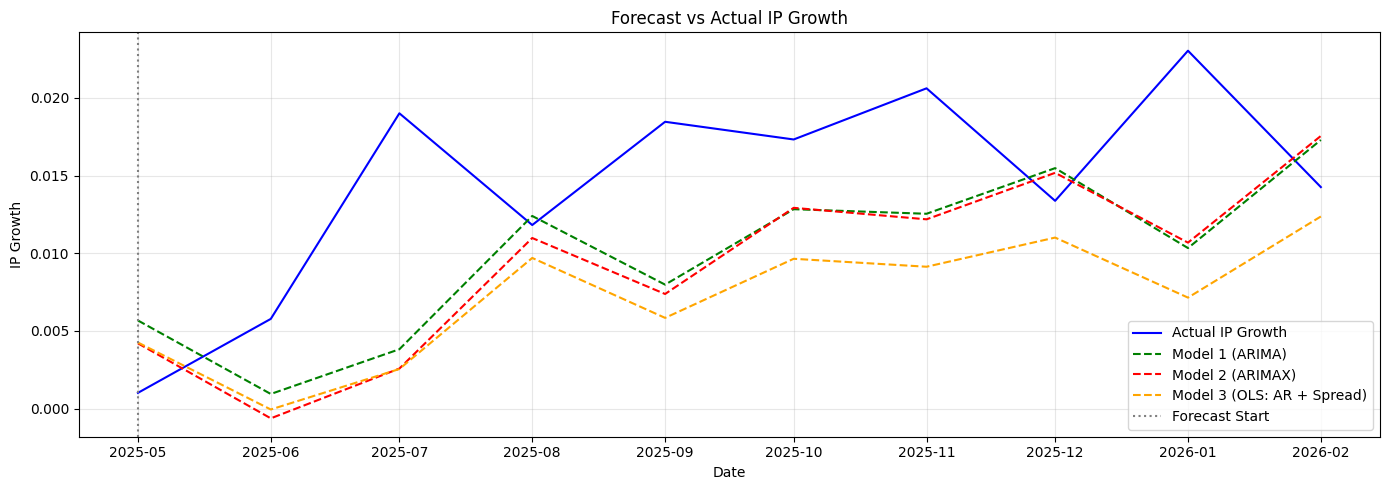

In [151]:
plt.figure(figsize=(14, 5))
plt.plot(test['observation_date'], ytest.values, label='Actual IP Growth', color='blue')
plt.plot(test['observation_date'], pred1_test, label='Model 1 (ARIMA)', color='green', linestyle='--')
plt.plot(test['observation_date'], pred2_test, label='Model 2 (ARIMAX)', color='red', linestyle='--')
plt.plot(test['observation_date'], pred3_test.values, label='Model 3 (OLS: AR + Spread)', color='orange', linestyle='--')
plt.axvline(x=test['observation_date'].iloc[0], color='gray', linestyle=':', label='Forecast Start')
plt.title('Forecast vs Actual IP Growth')
plt.xlabel('Date')
plt.ylabel('IP Growth')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()